# Laboratory 7: CLIP: a model to measure the similarity between image and text


This laboratory covers:

* Compressing a text description and an image into the same latent space
* Building and training a contrastive language image pretraining (CLIP) model to match text-image pairs
* Measuring the similarity between an image and a text description
* Using the trained CLIP model to select an image based on a text prompt
* Using the OpenAI pretrained CLIP to select an image based on text

In recent years, text-to-image models such as OpenAI's DALL-E 2, Google's Imagen, and Stability AI's Stable Diffusion, have garnered widespread attention for their ability to generate high-quality images based on text descriptions. These text-to-image models generally consist of three core components:

1. A text encoder to convert text into a latent representation.
2. A method to incorporate textual information into the image generation process.
3. A diffusion mechanism to gradually refine an image to produce a realistic output.

While we have discussed components (1) and (3) in early laboratories, we will zero in on the integration of text into image generation (component 2) in this laboratory.

In 2021, OpenAI released the contrastive language-image pretraining (CLIP) model.  This innovative model is designed to understand and interpret images in the context of natural language, a capability that holds immense potential for various applications such as image generation and image classification.

The CLIP model is a multimodal Transformer that bridges the gap between visual and textual data. It is trained to understand images by associating them with corresponding text descriptions. Unlike traditional models that require explicit labeling of images, CLIP uses a vast dataset of images and their natural language descriptions to learn a more generalizable representation of visual concepts.

To train the model, a large-scale training dataset of text-image pairs is collected. The text encoder of the model compresses the text description into a text embedding. The image encoder converts the corresponding image into an image embedding of the same dimension (say, both the text embedding and image embedding are represented by 256-value vectors). During training, a batch of N text-image pairs are converted to N text embeddings and N image embeddings. CLIP uses a contrastive learning approach to maximize the similarity between paired embeddings while minimizing the similarity between embeddings from non-matching text-image pairs.

In this laboratory, we will learn to create a CLIP model from scratch and use the image-caption pairs in the Flickr 8k dataset to train the model. Once the model is trained, we can perform an "image selection" task as follows. We enter a text description and use the trained model to select an image that best matches the text description. The experiment is not exactly "text-to-image generation", but can be considered "text-to-image selection". For many text descriptions such as "a dog walks on the beach" or "people eating in the restaurant", the selected images match the text descriptions well.

OpenAI has made its pretrained CLIP model public. Later in this course, we will rely mainly on this pretrained model in many text-to-image generation projects. Since OpenAI's CLIP model is trained on a large number of text-image pairs, the model can provide a more generalizable representation of visual concepts. We will learn how to select an image from the Flickr 8k dataset based on a text description using the pretrained OpenAI CLIP model.

# 1. Preparing the training dataset
We will use the Flickr 8k dataset to train the CLIP model in this laboratory. As we have learned in Laboratory 3, the Flickr 8k dataset is a collection of $8,091$ photographs sourced from the Flickr website, each annotated with five different descriptive captions provided by human annotators. In this laboratory, our purpose is to select images from the dataset based on a text prompt.

This section walks us through the steps in downloading the dataset, splitting them into a train and test set, and placing them in batches for training later. Before we start, run the following line of code to install a few libraries:

In [1]:
!pip install timm albumentations ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00


## 1.1.	Image-caption pairs in Flickr 8k
As we discussed in Laboratory 3, we can download the Flickr 8k images and the associated text captions from Kaggle. We copy everything in the folder `files`.


In [2]:
import kagglehub, shutil

path = kagglehub.dataset_download("adityajn105/flickr8k")
shutil.copytree("/kaggle/input/flickr8k/Images","files/Images")
shutil.copy("/kaggle/input/flickr8k/captions.txt","files")

Using Colab cache for faster access to the 'flickr8k' dataset.


'files/captions.txt'

We will first use the `pandas` library to load the captions for these images as follows:

In [3]:
import pandas as pd

df=pd.read_csv(r'files/captions.txt',
               delimiter=",")

We have to use the `delimiter=","` argument in the `read_csv()` method in the
`pandas` library because each row in the file `captions.txt` is separated into two columns
by a comma (“,”). We can print out the first $12$ observations as follows:

In [4]:
print(df.head(n=12))

                        image  \
0   1000268201_693b08cb0e.jpg   
1   1000268201_693b08cb0e.jpg   
2   1000268201_693b08cb0e.jpg   
3   1000268201_693b08cb0e.jpg   
4   1000268201_693b08cb0e.jpg   
5   1001773457_577c3a7d70.jpg   
6   1001773457_577c3a7d70.jpg   
7   1001773457_577c3a7d70.jpg   
8   1001773457_577c3a7d70.jpg   
9   1001773457_577c3a7d70.jpg   
10  1002674143_1b742ab4b8.jpg   
11  1002674143_1b742ab4b8.jpg   

                                              caption  
0   A child in a pink dress is climbing up a set o...  
1               A girl going into a wooden building .  
2    A little girl climbing into a wooden playhouse .  
3   A little girl climbing the stairs to her playh...  
4   A little girl in a pink dress going into a woo...  
5          A black dog and a spotted dog are fighting  
6   A black dog and a tri-colored dog playing with...  
7   A black dog and a white dog with brown spots a...  
8   Two dogs of different breeds looking at each o...  
9     Two 

As we can see, each image has five text descriptions.

Next, we can visualize $10$ images with their shortest captions as follows:

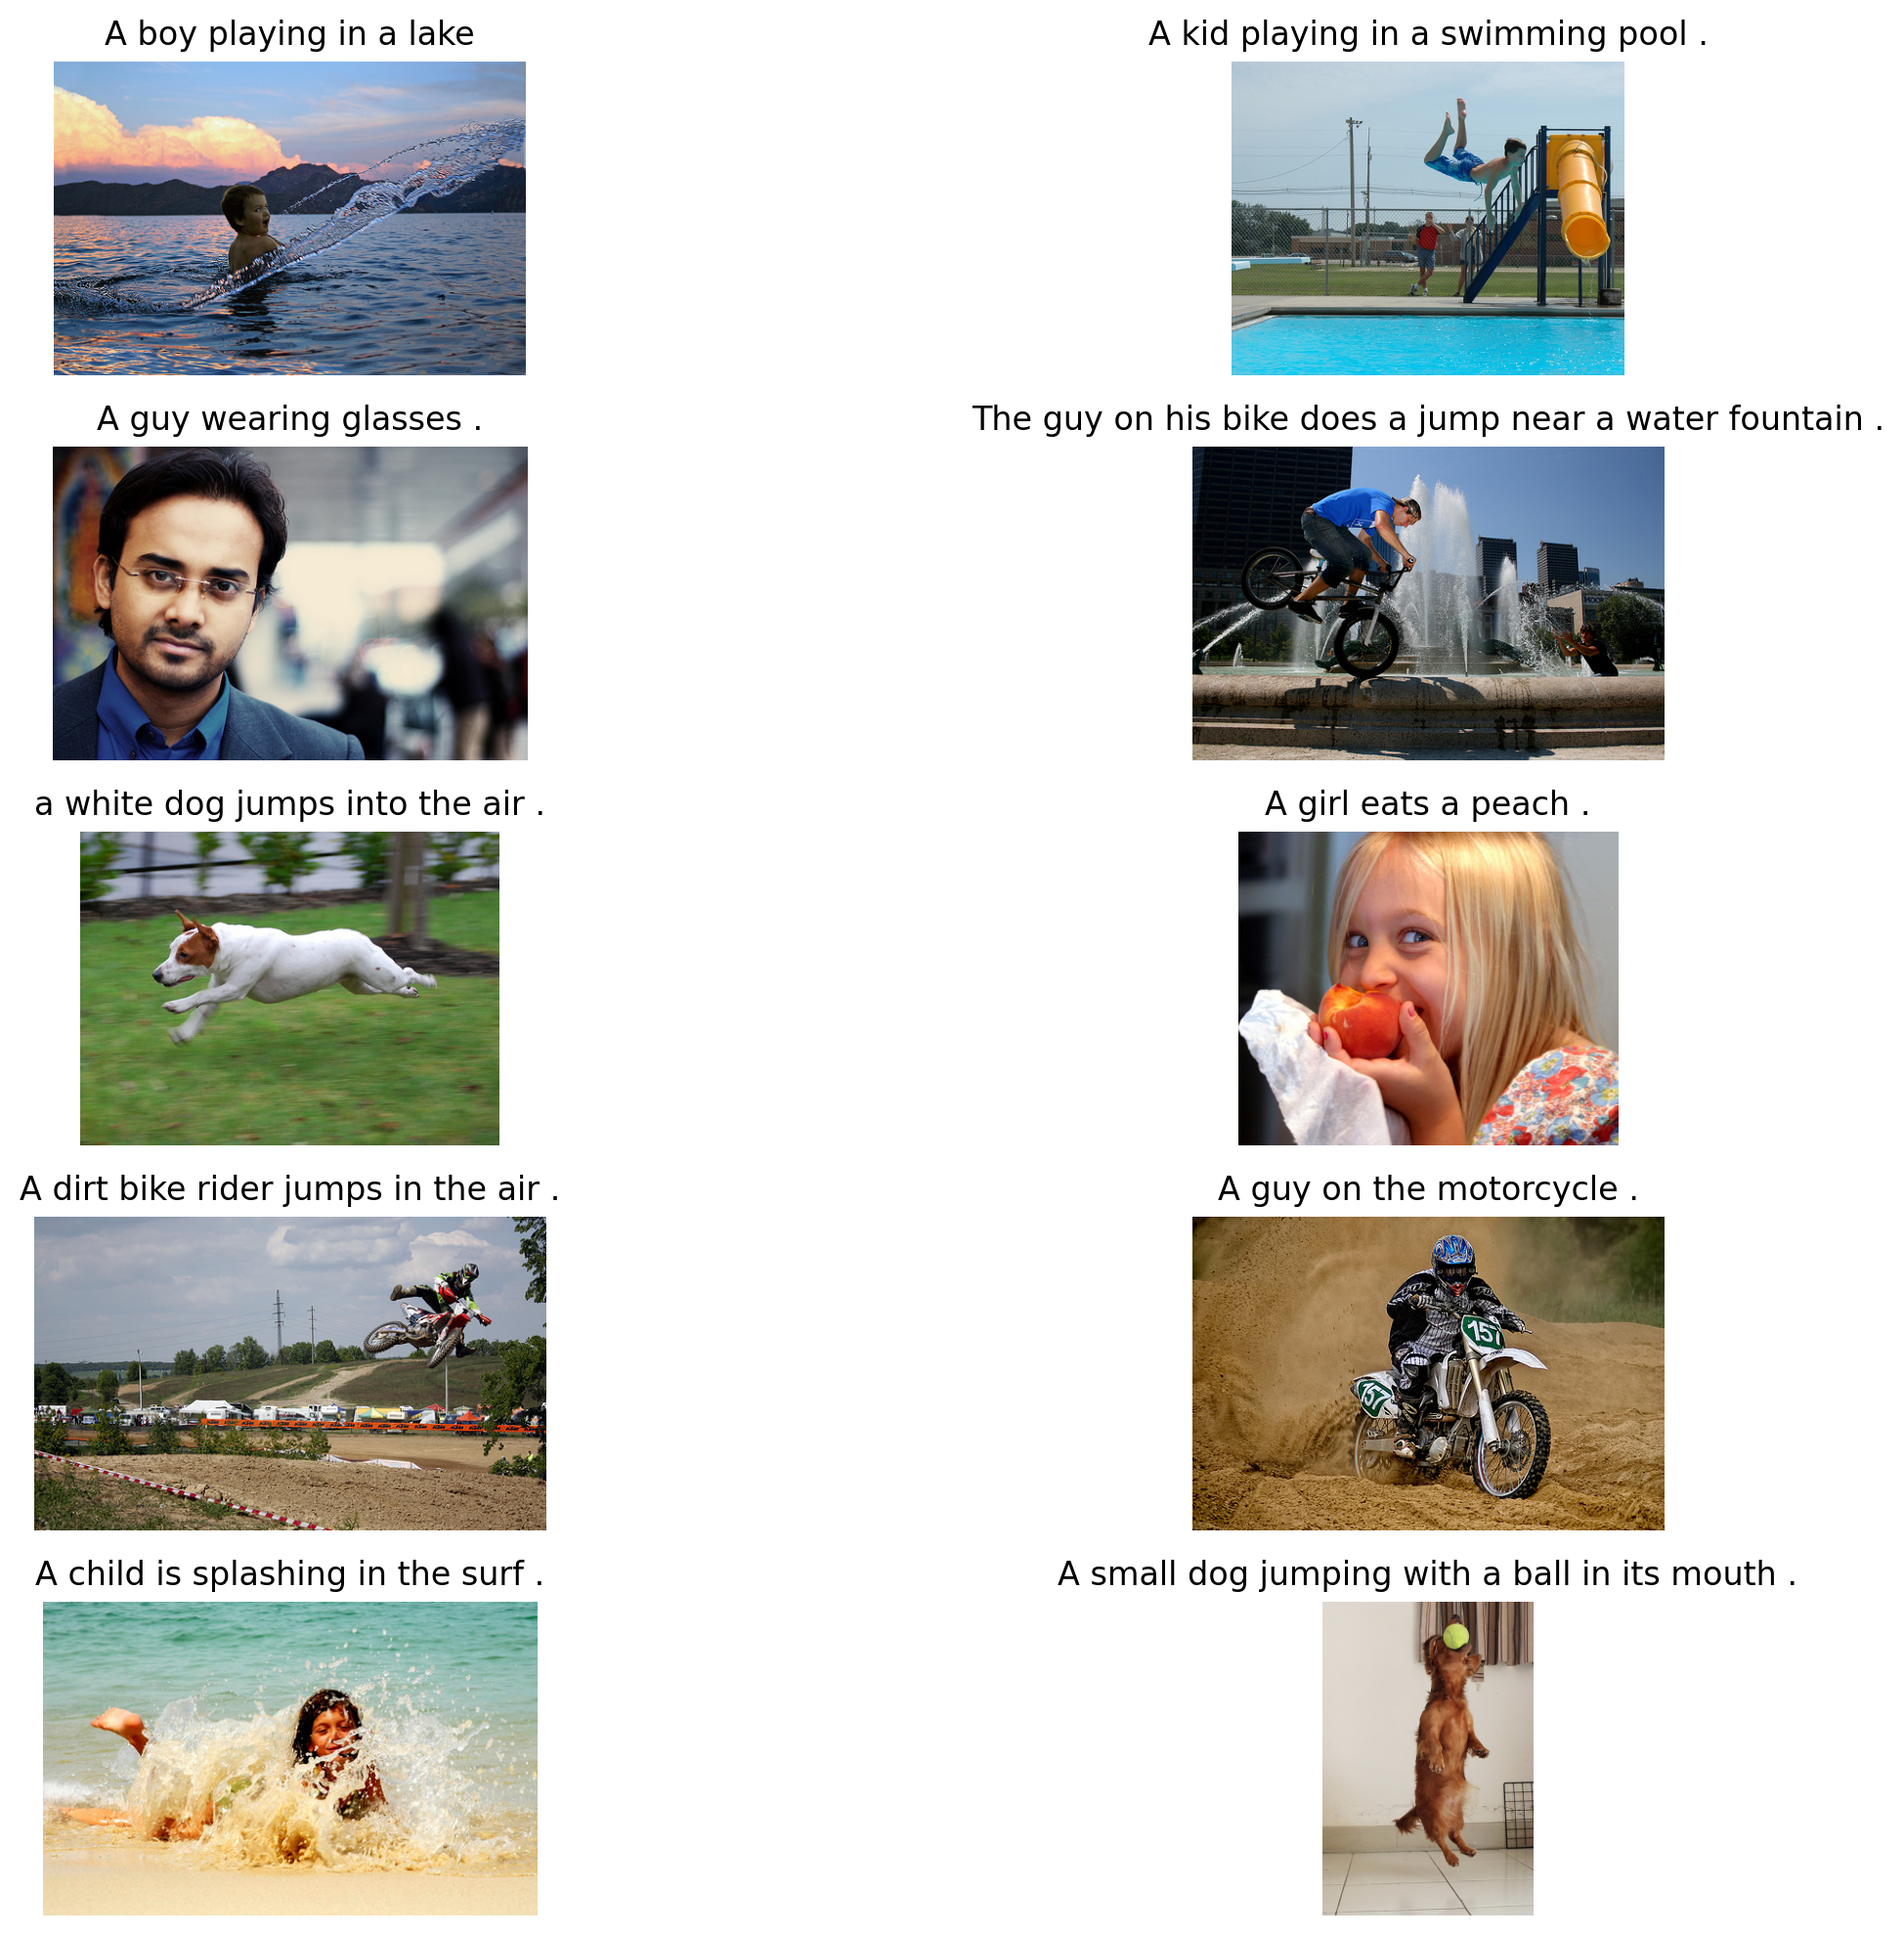

In [5]:
imgfolder=r"files/Images"
import os
with os.scandir(imgfolder) as fb:
    files=[f.name for f in fb]
start=100
imgs=files[start:start+10]    #Selects 10 images
dfi=df[df["image"].isin(imgs)].copy()
dfi["length"]=dfi["caption"].str.len()
dfi=dfi.sort_values(['image',"length"])
dfi=dfi.groupby("image").first()    #Selects the shortest caption for each image

import PIL
from matplotlib import pyplot as plt
plt.figure(dpi=200,figsize=(15,10))
for i in range(10):
    plt.subplot(5,2, i+1)    #Plots the 10 images in five rows and two columns
    img=f"{imgfolder}/{dfi.index[i]}"
    nparray=PIL.Image.open(img)
    plt.imshow(nparray)
    plt.title(f"{dfi.iloc[i]['caption']}")    #Places the caption on top of the image
    plt.axis("off")
plt.tight_layout()
plt.show()

We select $10$ images from the Flickr 8k dataset. Because each image has five different
captions, we select the shortest one for each image so that the caption can fit on top of
each image. We plot the $10$ images in a $5 \times 2$ grid and set the caption as the title of each
image. After running the code block, we see a plot of $10$ images, as shown above. Next, we will process the captions and images and get them ready for training.

## 1.2.	The DistilBERT tokenizer

Because deep neural networks can not directly process raw text or image files, we will first
preprocess captions and images into representations that the CLIP model can accept
as inputs. In particular, we will use the DistilBERT tokenizer to convert the raw text in
captions into tokens (parts of words) first. We will then insert two special tokens, `CLS`
and `SEP`, at the beginning and the end of each sentence. This is similar to what we have
done in Laboratory 3 when training a model to add captions to images. Further, we will pad
shorter sentences in a batch with $0$s so that all captions in a batch have the same length,
similar to what we have done in Laboratory 1. To see how the DistilBERT tokenizer works, we examine the following code:

In [6]:
from transformers import DistilBertTokenizer    #Imports the DistilBERT tokenizer from the transformers library

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased")
encoded=tokenizer(
    ["two dogs run",
    "an eagle flies in the sky"],
    padding=True, truncation=True,
    max_length=200)    #Generates input indexes and attention masks for a batch of two captions
print(encoded)
for indexes in encoded['input_ids']:
    tokens = tokenizer.convert_ids_to_tokens(indexes)
    print(tokens)    #Prints out the individual tokens in the two captions

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [[101, 2048, 6077, 2448, 102, 0, 0, 0], [101, 2019, 6755, 10029, 1999, 1996, 3712, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1]]}
['[CLS]', 'two', 'dogs', 'run', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'an', 'eagle', 'flies', 'in', 'the', 'sky', '[SEP]']


We use two hypothetical captions as our example: “two dogs run” and “an eagle flies in
the sky”. We put the two captions as a batch and feed them to the DistilBERT tokenizer.
The preceding output shows that the tokens for the first caption are `['[CLS]', 'two', 'dogs', 'run', '[SEP]', '[PAD]', '[PAD]', '[PAD]']`. The `CLS` token signals the start of
the caption, while the `SEP` token signals the end of the caption. Furthermore, because
the first caption is shorter than the second one, three padding tokens, `PAD`, are added
to the end of the sequence to make two sequences the same length. The tokens for the
second caption are `['[CLS]', 'an', 'eagle', 'flies', 'in', 'the', 'sky', '[SEP]']`.
The special tokens `CLS` and `SEP` are inserted into the beginning and the end of the
sequence. Because the second caption is the longest one in the batch, no padding
token is added to the sequence.

The attention mask for the first caption is `[1, 1, 1, 1, 1, 0, 0, 0]`, which tells the
model to pay attention to the first five tokens while ignoring the remaining three padding
tokens. The attention mask for the second caption is `[1, 1, 1, 1, 1, 1, 1, 1]`, which
tells the model to pay attention to all eight tokens because there is no padding token in
the second sequence.

## 1.3.	Preprocessing captions and images for training


Now that we understand how the DistilBERT tokenizer works, we preprocess the raw
text and image data into PyTorch tensors so that we can use them to train the CLIP
model later. We first split the dataset into train and validation subsets:

In [7]:
import numpy as np
image_ids = np.arange(0, len(df))
np.random.seed(42) #Fixes the random state so results are reproducible
valid_ids = np.random.choice( #Uses 20% of the sample as the validation set
    image_ids, size=int(0.2 * len(df)), replace=False)
train_ids = [id_ for id_ in image_ids if id_ not in valid_ids] #The remaining 80% of the sample is the train subset.
train = df[df.index.isin(train_ids)].reset_index(drop=True)
valid = df[df.index.isin(valid_ids)].reset_index(drop=True)

We use 20% of the sample as the validation subset and the remaining 80% of the sample
as the train subset.

We define a `CFG` class to store all hyperparameters used in this laboratory, as follows:

In [8]:
import torch

class CFG:
    image_path = r"files/Images"
    captions_path = r"files"
    batch_size = 32
    head_lr = 1e-3
    weight_decay = 1e-3
    patience = 1
    factor = 0.8
    epochs = 4
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_name = 'resnet50' #Uses the pretrained ResNet50 model to process images
    image_embedding = 2048
    text_encoder_model = "distilbert-base-uncased" #Uses the pretrained DistilBERT model to encode captions
    text_embedding = 768
    text_tokenizer = "distilbert-base-uncased"
    max_length = 200
    pretrained = True
    trainable = False
    temperature = 1.0
    size = 224 #Converts all images to a size of 3 × 224 × 224
    # for projection head; used for both image and text encoders
    num_projection_layers = 1
    projection_dim = 256 #Both text embeddings and image embeddings are 256-value vectors.
    dropout = 0.1

We will use the pretrained ResNet50 and DistilBERT models to encode images and captions,
respectively. All images will be converted to a standard size of $3 \times 224 \times 224$.
Both text embeddings and image embeddings are $256$-value vectors. The `CFG` class
has many other parameters that we will use later, and we will explain them as we go along.

We also define a `CLIPDataset` class to convert raw text and
image data in Flickr 8k into tensors as follows:

In [9]:
class CLIPDataset(torch.utils.data.Dataset):
    def __init__(self,image_filenames,captions,tokenizer,
                 transforms):
        self.image_filenames = image_filenames
        self.captions = list(captions)
        self.encoded_captions = tokenizer(
            list(captions), padding=True, truncation=True,
            max_length=CFG.max_length) #Uses the DistilBERT tokenizer to convert captions to tensors
        self.transforms = transforms
    def __getitem__(self, idx):
        item = {key: torch.tensor(values[idx])
            for key, values in self.encoded_captions.items()}
        image = cv2.imread(
            f"{CFG.image_path}/{self.image_filenames[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']
        item['image']=torch.tensor(image).permute(2,0,1).float() #Converts raw image data to tensors
        item['caption'] = self.captions[idx]
        return item #Each item consists of an image–caption pair.
    def __len__(self):
        return len(self.captions)

The `CLIPDataset` class uses the DistilBERT tokenizer to convert captions into tokens
and then sequences of indexes, with each index representing a token. The class also converts the corresponding image from the raw image data into a standard shape of
$(3, 224, 224)$—three color channels, with a height and width of $224$ pixels.

Below, we apply the `CLIPDataset` class on both the train and validation
subsets. We also place them in batches, with a batch size of $32$.

In [10]:
import albumentations as A

def get_transforms():
    return A.Compose([
            A.Resize(CFG.size, CFG.size, always_apply=True),
            A.Normalize(max_pixel_value=255.0,
                        always_apply=True),])

In [11]:
from transformers import (DistilBertModel, DistilBertConfig,
                          DistilBertTokenizer)

tokenizer = DistilBertTokenizer.from_pretrained(
    CFG.text_tokenizer) #Instantiates the DistilBERT tokenizer
transforms = get_transforms()
trainset = CLIPDataset(train["image"].values,
    train["caption"].values,tokenizer=tokenizer,
                       transforms=transforms)
trainloader = torch.utils.data.DataLoader(trainset,
    batch_size=CFG.batch_size,shuffle=True) #Applies the CLIPDataset class on the train subset and creates a data loader
valset = CLIPDataset(valid["image"].values,
    valid["caption"].values,tokenizer=tokenizer,
                     transforms=transforms)
valloader = torch.utils.data.DataLoader(valset,
    batch_size=CFG.batch_size,shuffle=False) #Applies the CLIPDataset class on the validation subset and creates a data loader

/tmp/ipykernel_18907/2949225460.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(CFG.size, CFG.size, always_apply=True),
/tmp/ipykernel_18907/2949225460.py:6: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0,


We apply the `CLIPDataset` class on both the train and validation subsets and create
two data loaders. We will use the data loaders to train and test the CLIP model later in
the laboratory. To get a sense of what the training data looks like, we can retrieve the first
batch in the train loader and print out the components in the data:

In [12]:
import cv2

batch0=next(iter(trainloader))
print(batch0.keys())

dict_keys(['input_ids', 'attention_mask', 'image', 'caption'])


Each batch is a Python dictionary with four key–value pairs. The keys are `input_ids`,
`attention_mask`, `image`, and `caption`. We can print out the value or the shape of the
components in the first observation as follows:

In [13]:
print(batch0['input_ids'][0])
print(batch0['attention_mask'][0])
print(batch0['image'][0].shape)
print(batch0['caption'][0])

tensor([ 101, 1037, 2158, 1999, 2417, 9132, 3061, 2006, 5749, 2011, 1037, 5460,
         102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
torch.Size([3, 224, 224])
A man in red shorts standing on rocks by a stream


The `input_ids` for a caption is a sequence of integers. The sequence is padded with `0` at
the end to ensure that all sequences in the batch have the same length. The `attention_mask` tensor masks out the paddings so the model pays attention only to the indexes
corresponding to the captions, not to the padded `0`s at the end of the sequence. Each
image is now represented by a tensor with a size of $(3, 224, 224)$. The original caption
is also included in the dictionary, which says, “A man is carefully skiing down a snow-covered
hill wearing a backpack”. Note that because data batches are randomly shuffled,
your result is likely different. Next, we will create a CLIP model and use the data to
train the model so that it can match captions to images.

# 2. Creating a CLIP model

Now that we have the training data ready, we will move on to creating a CLIP model.
The model consists of a text encoder and an image encoder that work together to
convert an image and its corresponding captions into two $256$-dimensional vectors.
This transformation lays the groundwork for training the model to align these two
representations. In the following section, we will use the prepared data to train the
model to associate captions with images. Once training is complete, we can input
any text prompt, and the CLIP model will retrieve the image that best matches the
description.

## 2.1. Creating a text encoder


The text encoder in our CLIP model converts sequences of indexes, which represent
tokens in the text descriptions of the images, into embeddings in the latent space.
Later, we will create an image encoder that converts an image into an embedding of the
same length in the same latent space. We define the
`TextEncoder` class, as shown in the following code.

In [14]:
from torch import nn

class TextEncoder(nn.Module):
    def __init__(self, model_name=CFG.text_encoder_model,
                 pretrained=CFG.pretrained,
                 trainable=CFG.trainable):
        super().__init__()
        if pretrained:
            self.model=DistilBertModel.from_pretrained(model_name)
        else:
            self.model=DistilBertModel(config=DistilBertConfig())
        for p in self.model.parameters():
            p.requires_grad = trainable
        self.target_token_idx = 0 #Focuses only on the first token in the caption (the starting token CLS)
    def forward(self, input_ids, attention_mask):
        output = self.model(input_ids=input_ids,
                attention_mask=attention_mask)
        last_hidden_state = output.last_hidden_state #Uses the last layer of the pretrained DistilBERT model
        return last_hidden_state[:,self.target_token_idx,:] #The text embedding is the output associated with the CLS token in the last layer.

In Laboratory 2, when constructing a vision transformer (ViT), we inserted a `CLS` token
into the image token sequence. This token is not related to any particular part of the
image; instead, it aggregates information from the entire image for classification. We
adopt a similar strategy when creating a text embedding for a caption in this laboratory.
Here, the CLS token is not tied to an individual word in the caption but serves as a
summary of the entire caption. Consequently, we focus only on the first token, the `CLS`
token.

Of the many different layers in the DistilBERT model, we will use the last layer. As input
flows through different layers, the representations become more abstract and refined.
The final layer has integrated information from all previous layers. Therefore, the text
embedding for the caption is the output associated with the CLS token in the very last
layer.

Instead of training a text encoder from scratch, we will use the pretrained DistilBERT
model from Hugging Face to reduce the training time. We can count the number of
trainable and untrainable parameters in the text encoder defined earlier:

In [15]:
textencoder=TextEncoder()
num_trainable = sum([p.numel() for p in
    textencoder.parameters() if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable = sum([p.numel() for p in
    textencoder.parameters() if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of trainable parameters: 0
Number of untrainable parameters: 66362880


The DistileBert model has more than 66 million parameters. By turning off the trainable argument, we can speed up the training process.

An additional benefit of using the embedding of the `CLS` token in the very last layer
as the text embedding for the whole caption is the fixed-length output. No matter what
the length of the caption is, the size of the text embedding is the same.

We can apply the text encoder on the first batch of training data:

In [16]:
encoded_text=textencoder(batch0['input_ids'],
                         batch0['attention_mask'])
print(encoded_text.shape)

torch.Size([32, 768])


We feed the input indexes and attention masks in the first batch to the text encoder,
and the output has a shape of $(32, 768)$. There are $32$ captions in the batch, and each
caption is converted into a $768$-value vector. Later, we will pass this $768$-value vector
through a projection head to generate a $256$-value vector, which will be our final text
embedding.

## 2.2. Creating an image encoder
We will use the ResNet50 model from the `timm` library as our image encoder. We define the `ImageEncoder` class:

In [17]:
import timm

class ImageEncoder(nn.Module):
    def __init__(self, model_name=CFG.model_name, #Uses ResNet50 as the image encoder
                 pretrained=CFG.pretrained, #Uses the pretrained model instead of training from scratch
                 trainable=CFG.trainable): #Sets the trainable argument to False
        super().__init__()
        self.model = timm.create_model(model_name, pretrained,
            num_classes=0,global_pool="avg")
        for p in self.model.parameters():
            p.requires_grad = trainable
    def forward(self, x):
        return self.model(x)

We will use the pretrained weights to reduce the number of trainable parameters and
eventually the training time. To count the number of trainable and untrainable parameters
in the image encoder defined previously, we run the following code cell:

In [18]:
imageencoder=ImageEncoder()
num_trainable = sum([p.numel() for p in imageencoder.parameters()
                     if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable = sum([p.numel() for p in imageencoder.parameters()
                     if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Number of trainable parameters: 0
Number of untrainable parameters: 23508032


The ResNet50 model has more than 23 million parameters. By turning off the `trainable` argument, we can speed up the training process.

We can apply the image encoder on the first batch of the training data and print out
the shape of the output:

In [19]:
encoded_image=imageencoder(batch0['image'])
print(encoded_image.shape)

torch.Size([32, 2048])


We feed the images in the first batch to the image encoder, and the output has a shape
of $(32, 2048)$. There are $32$ images in the batch, and each image is converted into a
$2,048$-value vector. Later, we will pass each vector through a projection head to produce a
$256$-value image embedding.

## 2.3.	Building a CLIP model
We may have noticed that each caption is converted to a $768$-value vector, while each
image is converted to a $2,048$-value vector. To make the dimensions of the text embedding
and image embedding the same, we define the following `ProjectionHead` class.

In [20]:
class ProjectionHead(nn.Module):
    def __init__(self,embedding_dim, #The dimension of the input (768 for text and 2,048 for image)
        projection_dim=CFG.projection_dim, #The dimension of the output (256 for both text and image)
        dropout=CFG.dropout):
        super().__init__()
        self.projection = nn.Linear(embedding_dim,
                                    projection_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(projection_dim, projection_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(projection_dim)
    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected
        x = self.layer_norm(x) #The input goes through the two linear layers, GELU activation, and a dropout layer, with residual connection and layer normalization.
        return x

The `embedding_dim` argument in the `ProjectionHead` class specifies the dimension
of the input, which is $768$ for text and $2,048$ for image. The `projection_dim` argument
is the dimension of the output, which is $256$ for both text and image. We will instantiate
a text projection head and an image projection head later. The projection heads convert
both text features and image features into $256$-value vectors so that we can train
the CLIP model to match the two embeddings, that is, to make the values in the two
embeddings as close to each other as possible.

The CLIP model aligns images and texts by mapping both modalities into a shared
embedding space, enabling direct comparison between image and text representations.
The CLIP model is defined in the local module as shown in the following:

In [21]:
def cross_entropy(preds, targets, reduction='none'):
    log_softmax = nn.LogSoftmax(dim=-1)
    loss = (-targets * log_softmax(preds)).sum(1)
    if reduction == "none":
        return loss
    elif reduction == "mean":
        return loss.mean()

In [22]:
import torch.nn.functional as F

class CLIPModel(nn.Module):
    def __init__(self,temperature=CFG.temperature,
        image_embedding=CFG.image_embedding,
        text_embedding=CFG.text_embedding):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projection = ProjectionHead(
            embedding_dim=image_embedding)
        self.text_projection = ProjectionHead(
            embedding_dim=text_embedding)
        self.temperature = temperature
    def forward(self, batch):
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        ) #Uses the image encoder and text encoder to extract features
        image_embeddings = self.image_projection(image_features)
        text_embeddings = self.text_projection(text_features) #Uses projection heads to generate image and text embeddings
        logits = \
        (text_embeddings @ image_embeddings.T) / self.temperature
        images_similarity = image_embeddings @ image_embeddings.T
        texts_similarity = text_embeddings @ text_embeddings.T
        targets = F.softmax(
        (images_similarity +
         texts_similarity) / 2 * self.temperature,
        dim=-1)
        texts_loss = cross_entropy(logits, targets,
                                   reduction='none')
        images_loss = cross_entropy(logits.T, targets.T,
                                    reduction='none')
        loss =  (images_loss + texts_loss) / 2.0 #Calculates the loss to maximize the similarity between image and text embeddings
        return loss.mean()

The model encodes each image and each caption (text) into a fixed-length vector (size
$256$). For a batch of $32$ image–text pairs, both `image_embeddings` and `text_embeddings`
tensors have shape $(32, 256)$.

The main similarity matrix is computed as `text_embeddings@image_embeddings.T`,
resulting in a $(32, 32)$ matrix. Each element $(i, j)$ measures how similar the $i$-th text is to
the $j$-th image. This is the primary comparison used for training.

The model also uses two other matrices, `image_embeddings@image_embeddings.T`
and `text_embeddings@text_embeddings.T`, which are `images_similarity` and `texts_similarity`.
They measure how similar each embedding is to every other embedding of
the same type within the batch (image-to-image and text-to-text, respectively).

This step is not used for the main matching objective, but rather for target smoothing:
by averaging the image-to-image and text-to-text similarities, we produce softer, more
informative targets for the cross-entropy loss instead of only relying on strict one-hot
labels. This can help the model learn more robust and meaningful representations by
recognizing that some images (or texts) in a batch may be semantically similar, even if
they are not the exact match.

The soft targets are created by taking the average of the image and text similarity
matrices and applying a softmax (with temperature scaling). This approach encourages
the model to distribute some probability mass to similar (but not identical) examples,
making the loss less brittle.

Cross-entropy loss is computed for both text-to-image and image-to-text directions
and then averaged. This symmetric approach ensures both encoders are trained equally
to align the representations.

The model is trained so that the embeddings of matching image–text pairs are close
together and nonmatching pairs are far apart. The image-to-image and text-to-text similarity
computations are used to soften the target labels and improve training, not as the
primary measure of performance.

# 3.	Training and using the CLIP model

Now that we have both the training data and the CLIP model, we will train the model to
match images with captions. After that, we will use the trained model to select an image
from the Flickr 8k dataset based on a given text prompt.

## 3.1. Training the CLIP model

We first instantiate the `CLIPModel` class to create our CLIP model:

In [23]:
model = CLIPModel().to(CFG.device) #Instantiates the CLIPModel to create our CLIP model
num_trainable = sum([p.numel() for p in model.parameters()
                     if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable = sum([p.numel() for p in model.parameters()
                     if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}") #Prints out the number of trainable and untrainable parameters

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of trainable parameters: 854016
Number of untrainable parameters: 89870912


Because we use pretrained weights from the DistilBERT model for text encoding
and the ResNet50 model for image encoding, our model has only $854,016$ trainable
parameters.

Here, we define the optimizer and the learning rate scheduler as follows:

In [24]:
import itertools

params = [
    {"params": itertools.chain(
        model.image_projection.parameters(),
        model.text_projection.parameters()
    ), "lr": CFG.head_lr, "weight_decay": CFG.weight_decay}
]
optimizer = torch.optim.AdamW(params, weight_decay=0.)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=CFG.patience,
    factor=CFG.factor
)

We will train the model for $10$ epochs. We test the performance of the model after each
epoch and save the best model based on model performance on the validation set.
Therefore, we define an `evaluate()` function first, as shown in the following.

In [25]:
def evaluate():
    global best_loss
    model.eval()
    losses = []
    with torch.no_grad():
        tqdm_object = tqdm(valloader, total=len(valloader))
        for batch in tqdm_object:    #Iterates through all batches in the validation set
            batch = {k: v.to(CFG.device) for k, v in
                     batch.items() if k != "caption"}
            loss = model(batch)
            losses.append(loss.item())
            avgloss=sum(losses)/len(losses)    #Calculates the average loss in the epoch
            tqdm_object.set_description(
                f"valid_loss={avgloss:.2f}")
    if avgloss < best_loss:
        best_loss = avgloss
        torch.save(model.state_dict(), "files/best.pth")    #If the performance of the model is the best among all epochs, saves the model parameters
        print("Saved Best Model!")

The `evaluate()` function measures the model's performance using the validation set.
It processes each batch in the set, computing the loss for each. The epoch's average
loss is then calculated by averaging the losses from all batches. If the model performance
in this epoch is better than that in all previous epochs, the function saves the
model parameters to the `files` folder. We can now go ahead and
train the model.

In [26]:
scaler = torch.amp.GradScaler("cuda")
best_loss = float('inf')
from tqdm import tqdm
for epoch in range(10):
    print(f"Epoch: {epoch + 1}")
    model.train()
    losses = []
    tqdm_object = tqdm(trainloader, total=len(trainloader))
    for batch in tqdm_object:    #Iterates through all batches in the training set
        batch = {k: v.to(CFG.device) for k, v in
                 batch.items() if k != "caption"}
        with torch.amp.autocast("cuda"):
            loss = model(batch)    #Calculates the loss in the batch
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()    #Adjusts model parameters to minimize the loss
        losses.append(loss.item())
        avgloss=sum(losses)/len(losses)
        tqdm_object.set_description(f"loss is {avgloss:.5f}")
    evaluate()    #Evaluates the current model and saves model parameters if it achieves the best performance so far
    lr_scheduler.step(avgloss)

Epoch: 1


loss is 10.35139:   4%|▍         | 40/1012 [00:19<07:54,  2.05it/s]


KeyboardInterrupt: 

The best model is achieved after eight epochs of training. The trained model is saved
as `best.pth` in the `files` folder. Alternatively, the trained model parameters can be download from Google Drive at https://drive.google.com/file/d/1H57jf5aaJFbPtRhmkaloKy4gV9gGuPSr/view?usp=drive_link. Unzip the
file after downloading.

## 3.2.	Using the trained CLIP model to select images

Next, we use the trained CLIP model to select an image from the validation set based
on a text prompt. Here, we load the trained model parameters:

In [30]:
sd=torch.load(r"/content/files/best.pth")
model.load_state_dict(sd)
model.eval()

CLIPModel(
  (image_encoder): ImageEncoder(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (drop_block): Identity()
          (act2): ReLU(inplace=True)
          (aa): Identity()
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1

We first obtain the image embeddings of all images in the validation set and use them
as potential candidates for a match for any text prompt:

In [31]:
image_embeds = []
with torch.no_grad():
    for batch in tqdm(valloader):
        image_features = model.image_encoder(
            batch["image"].to(CFG.device))
        image_embeds.append(
            model.image_projection(image_features))
image_embeddings = torch.cat(image_embeds)

100%|██████████| 253/253 [00:42<00:00,  5.96it/s]


We save the image embeddings so that we do not need to create image
embeddings again later when we perform more image-selection tasks:

In [32]:
import pickle

with open("files/image_embeds.p","wb") as f:
    pickle.dump(image_embeddings, f)

We define a `match()` function to select an image based on a prompt in the following:

In [33]:
def match(prompt):
    encoded = tokenizer([prompt])    #Tokenizes the prompt
    batch = {
        key: torch.tensor(values).to(CFG.device)
        for key, values in encoded.items()
    }
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )
        text_embeddings = model.text_projection(
        text_features)    #Creates a text embedding
    dot_similarity = text_embeddings @ image_embeddings.T
    values, idx = torch.topk(dot_similarity.squeeze(0), 1)    #Selects the image with the highest value of similarity with the text prompt
    img=valid['image'].values[idx.item()]
    caption=valid['caption'].values[idx.item()]
    return img, caption

The `match()` function takes a prompt as the input. It first converts the text into tokens
and then uses the trained CLIP model to convert the text prompt into a text embedding.
Next, the function calculates the cosine similarities between the text embedding
and all the image embeddings. The image with the highest similarity with the text
prompt is selected as the match. We can try the `match()` function using the prompt
“students having a class in the classroom”:

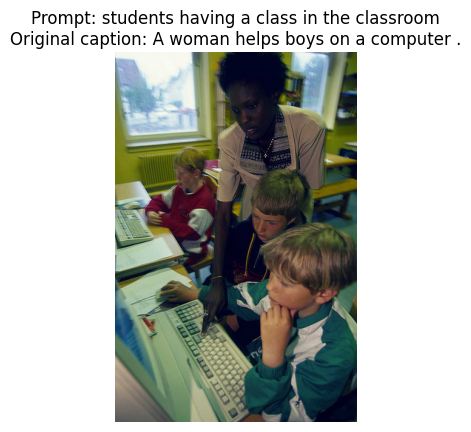

In [34]:
prompt="students having a class in the classroom"
file,cap=match(prompt) #Finds a match for the prompt
plt.imshow(PIL.Image.open(
    rf"files/Images/{file}"))
plt.title(f"Prompt: {prompt}\nOriginal caption: {cap}") #Displays the selected image, the prompt, and the original caption
plt.axis("off")
plt.show()

The `match()` function returns the
name of the matched image file and
the original caption associated with
the selected image. We display the
selected image and place both the text
prompt and the original caption above
the image. The output is shown above.

The selected image does show a
teacher and several students in a classroom.
The original caption of the
image is “a woman helps boys on a
computer”. Even though the prompt
is not the same as the original caption,
the selection matches the description
of the text prompt. This indicates
that we have successfully trained a CLIP
model.

## 3.3. Using the OpenAI pretrained CLIP model to select images



OpenAI has made its pretrained CLIP model public. Later in this laboratory, we will rely
mainly on that model because it is trained on more text–image pairs. Therefore, the
model can provide a more generalizable representation of visual concepts.
In this section, we will enter a text prompt and use the OpenAI pretrained CLIP model
to search for an image from the Flickr 8k database to match the text description. We will
first use the OpenAI pretrained CLIP model to encode all images in Flickr 8k. To do
that, we will clone the OpenAI GitHub repository and place it in the local folder so that
we can use the OpenAI CLIP model.
Run the following line of code:

In [35]:
!git clone https://github.com/openai/CLIP

Cloning into 'CLIP'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 265 (delta 1), reused 0 (delta 0), pack-reused 260 (from 2)
Receiving objects: 100% (265/265), 8.87 MiB | 10.70 MiB/s, done.
Resolving deltas: 100% (137/137), done.


Now all the files related to the OpenAI CLIP model are placed in the `CLIP` folder. We will use the `sys` library to give Python access to the folder as follows:

In [36]:
import sys

sys.path.append("./CLIP")

Next, we encode all images in the Flickr 8k dataset using the image encoder in the
OpenAI CLIP model.

In [40]:
import os

folder=r"files/Images"
with os.scandir(folder) as files:
    names=[file.name for file in files]

import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32",
device=device)    #Loads the pretrained OpenAI CLIP model
images=[]
for i in names:
    images.append(preprocess(Image.open(f"{folder}/{i}"
                            )).unsqueeze(0).to(device))
image=torch.cat(images[:1024])
print(image.shape)
with torch.no_grad():
    image_features = model.encode_image(image)    #Encodes all images in Flickr 8k
with open("files/imgfeas.p","wb") as fb:
    pickle.dump(image_features,fb)    #Saves the image embeddings for later use

torch.Size([1024, 3, 224, 224])


We first load the pretrained OpenAI CLIP model. We then use the image encoder in
the model to convert all images in Flickr 8k to image embeddings, which are saved in
the file `imgfeas.p` for later use. Next, we define a `find_match()` function
to find and display five images that best match a text prompt.

In [41]:
import PIL
from matplotlib import pyplot as plt

def find_match(prompt):
    print(f"prompt is {prompt}")
    text = clip.tokenize([prompt]).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text) #Encodes the text prompt into a text embedding
    simu=text_features@image_features.T #Calculates the similarities between the text and all images
    values, indices = torch.topk(simu[0], 5) #Selects the best-matched five images based on the similarities
    plots=[]
    for i in indices:
        plots.append(names[i])
    plt.figure(dpi=200,figsize=(10,2))
    for i in range(5): #Plots the five images in a 1 × 5 grid
        plt.subplot(1,5, i+1)
        img=f"{folder}/{plots[i]}"
        nparray=PIL.Image.open(img)
        plt.imshow(nparray)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

The function tokenizes the prompt and uses the pretrained OpenAI CLIP model to
convert the text into a text embedding. We then calculate the similarities between the
text embedding and all the image embeddings that we saved earlier. We select five
matches based on the highest similarity scores. We display the five matches in a $1 \times 5$
grid, with the left image the most likely match. Now we can load the image embeddings
and call the `find_match()` function to find matches:

prompt is people eating at the restaurant


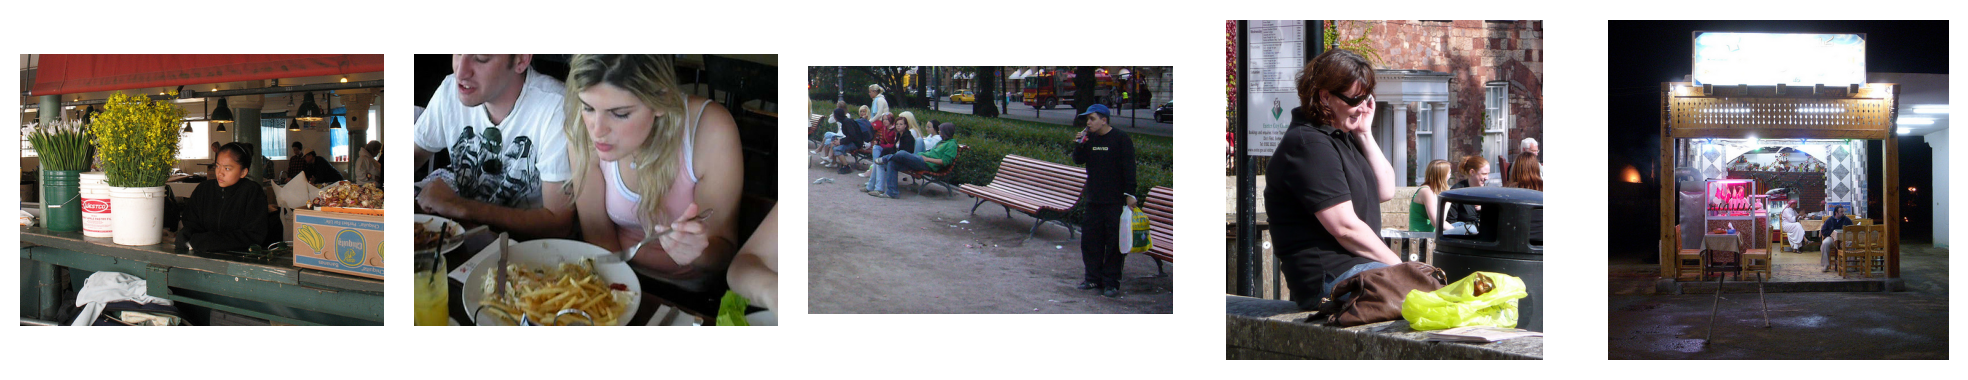

In [42]:
import pickle

with open("files/imgfeas.p","rb") as fb:
    image_features=pickle.load(fb)
find_match("people eating at the restaurant")

We entered the prompt "people eating at the restaurant" as the argument for the
function. The five matched images are displayed above.

The last image above fits the text prompt well. Note that our dataset is small.
If we apply the same method to a large dataset, say, with millions of images with diverse
settings, the match will be much closer to the text description.

# Exercises

1.   Use the `match()` function to select an image from the Flickr 8k dataset based on the
text prompt “dogs walk on the beach”. Plot the selected image, and place both the
text prompt and the original caption above the image.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


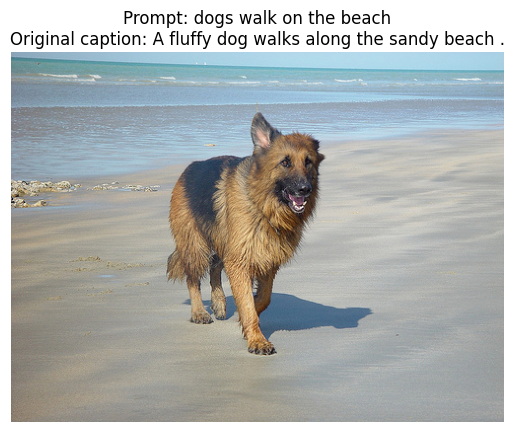

In [44]:
# Ex 1
# Re-instantiate the custom CLIPModel and load its weights for the 'match' function
model = CLIPModel().to(CFG.device)
sd = torch.load(r"files/best.pth")
model.load_state_dict(sd)
model.eval()

prompt = "dogs walk on the beach"
file, cap = match(prompt)
plt.imshow(PIL.Image.open(rf"files/Images/{file}"))
plt.title(f"Prompt: {prompt}\nOriginal caption: {cap}")
plt.axis("off")
plt.show()

2.   Use the `find_match()` function to select an image from the Flickr 8k dataset based on the text prompt “people shopping on the street”. Plot the selected images in a $1 \times 5$ grid.

prompt is people shopping on the street


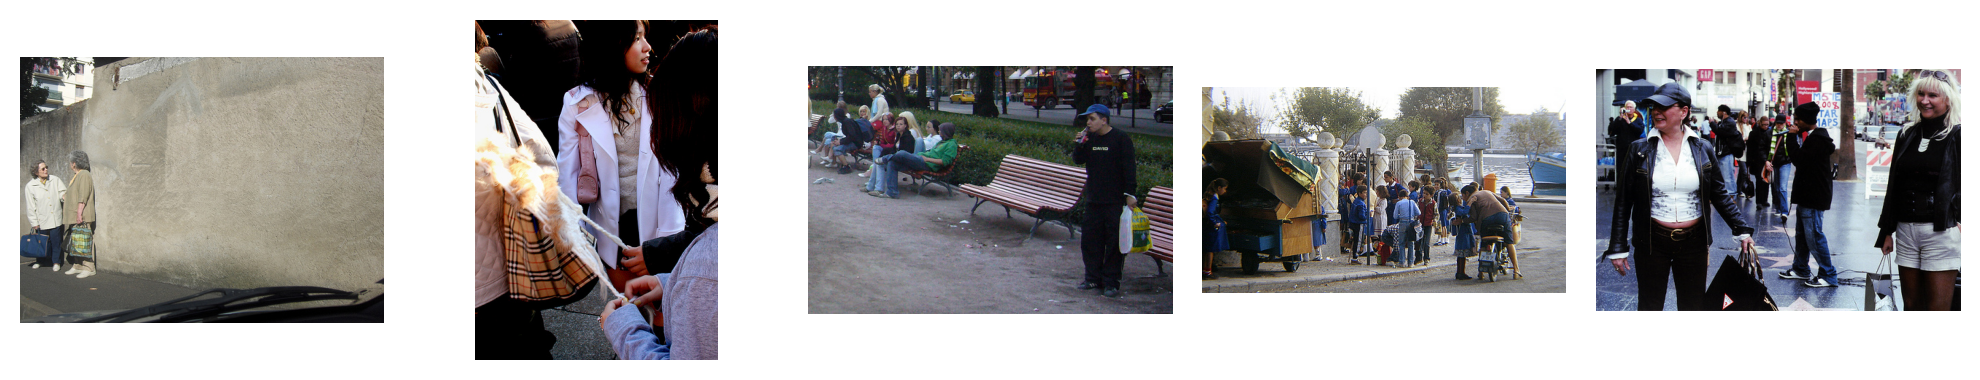

In [ ]:
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device) # Reload OpenAI CLIP model

find_match("people shopping on the street")